In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import PartialDependenceDisplay
import pickle



In [3]:
game_data = pd.read_csv("stats17-18 game data.csv")
game_data.head()

,GameID,Date,Year,Home_team,Away_Team,Home_winner?,Away_Winner?,Ratio A/T,APG,BKPG,...,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,13d9674b-ca71-4d68-989d-3debd0254e84,11-10-2017,2017,Baylor,Central Ark.,True,False,-0.06,-0.9,-0.6,...,1.7,9.5,-9.3,-4.9,4.4,-1.3,4.5,-2.3,0.1,-2.1
1,cc61e852-a300-479e-9b1c-01c8c347a194,11-10-2017,2017,Tulsa,Lamar,False,True,-0.06,-1.0,-0.1,...,0.3,1.0,1.3,-2.3,-3.6,-4.0,3.7,0.1,0.5,-0.4
2,e3163426-d26c-4c42-9ab8-4e168cb7c6f9,11-10-2017,2017,Virginia Tech,Detroit Mercy,True,False,0.37,2.7,-0.6,...,-2.1,2.0,-13.5,1.2,14.7,-0.8,38.6,-5.0,4.3,-1.0
3,1889b466-b38b-4421-8e61-712ffae45f54,11-10-2017,2017,Sacred Heart,Holy Cross,False,True,-0.23,-0.7,-1.1,...,11.6,13.8,4.5,5.1,0.6,-1.4,-6.4,-1.6,-2.7,-1.0
4,4e182efb-c4db-4351-9b07-a3014394d76e,11-10-2017,2017,Mississippi St.,Alabama St.,True,False,0.30,3.2,1.2,...,-0.4,5.3,-10.8,4.7,15.5,1.1,41.8,-4.5,-0.9,-0.7


In [4]:
game_data = game_data.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?"])
game_data.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,...,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,True,-0.06,-0.9,-0.6,0.26,1.6,-3.2,-0.1,1.50,-1.8,...,1.7,9.5,-9.3,-4.9,4.4,-1.3,4.5,-2.3,0.1,-2.1
1,False,-0.06,-1.0,-0.1,1.99,0.5,-2.7,6.8,-1.75,-3.8,...,0.3,1.0,1.3,-2.3,-3.6,-4.0,3.7,0.1,0.5,-0.4
2,True,0.37,2.7,-0.6,0.93,6.4,-5.2,-4.6,-3.08,-4.4,...,-2.1,2.0,-13.5,1.2,14.7,-0.8,38.6,-5.0,4.3,-1.0
3,False,-0.23,-0.7,-1.1,5.25,-2.4,0.9,-2.7,6.32,1.1,...,11.6,13.8,4.5,5.1,0.6,-1.4,-6.4,-1.6,-2.7,-1.0
4,True,0.30,3.2,1.2,1.53,5.6,-3.5,4.5,-1.95,-4.3,...,-0.4,5.3,-10.8,4.7,15.5,1.1,41.8,-4.5,-0.9,-0.7


In [5]:
x, y = game_data.loc[:, (game_data.columns != "Home_winner?")], game_data["Home_winner?"]
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.2, random_state=42)
xtrain, xval, ytrain, yval = train_test_split(xtrain,ytrain, test_size=.25, random_state=42)

In [6]:
label_encoder = LabelEncoder()
ytrain = label_encoder.fit_transform(ytrain)
yval   = label_encoder.transform(yval)
ytest  = label_encoder.transform(ytest)

In [7]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

In [129]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(xtrain,ytrain)

RandomForestClassifier(random_state=42)

In [130]:
ypred = rf_model.predict(xval)

In [131]:
test_accuracy = accuracy_score(yval, ypred)
print(f"Test_Accuracy: {test_accuracy: .3f}")
print("\nClasification Report:\n", classification_report(yval,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(yval,ypred))

Test_Accuracy:  0.736

Clasification Report:
               precision    recall  f1-score   support

           0       0.66      0.55      0.60       374
           1       0.77      0.84      0.80       663

    accuracy                           0.74      1037
   macro avg       0.71      0.69      0.70      1037
weighted avg       0.73      0.74      0.73      1037


Confusion Matrix:
 [[205 169]
 [105 558]]


In [1]:
feature_importance = rf_model.feature_importances_
feature_names = x.columns

sort_indices = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importance)), feature_importance[sort_indices], align="center")
plt.xticks(range(len(feature_importance)), np.array(feature_names)[sort_indices], rotation=90)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

NameError: name 'rf_model' is not defined

In [8]:
#Tuned RF
rf_model_tuned = RandomForestClassifier(class_weight="balanced", bootstrap=True, random_state=42, n_estimators=1000, max_depth=6, max_features='sqrt', min_samples_leaf=5, min_impurity_decrease=0.0, criterion='gini')
rf_model_tuned.fit(xtrain,ytrain)

RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=5,
                       n_estimators=1000, random_state=42)

In [12]:
y_tuned_pred = rf_model_tuned.predict(xval)

In [15]:
test_accuracy = accuracy_score(yval, y_tuned_pred)
print(f"Test_Accuracy: {test_accuracy: .3f}")
print("\nClasification Report:\n", classification_report(yval,y_tuned_pred))
print("\nConfusion Matrix:\n", confusion_matrix(yval,y_tuned_pred))

Test_Accuracy:  0.734

Clasification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.65       374
           1       0.81      0.77      0.79       663

    accuracy                           0.73      1037
   macro avg       0.71      0.72      0.72      1037
weighted avg       0.74      0.73      0.74      1037


Confusion Matrix:
 [[252 122]
 [154 509]]


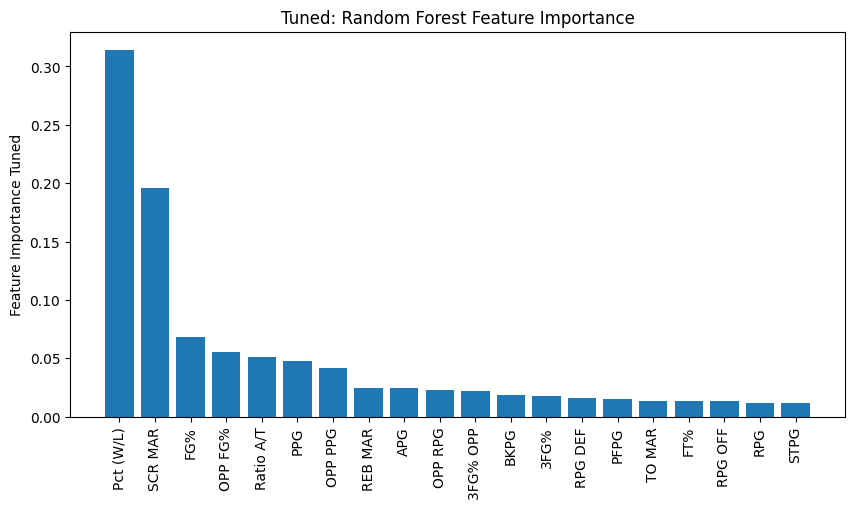

In [16]:
feature_importance_tuned = rf_model_tuned.feature_importances_
feature_names = x.columns

sort_indices = np.argsort(feature_importance_tuned)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importance_tuned)), feature_importance_tuned[sort_indices], align="center")
plt.xticks(range(len(feature_importance_tuned)), np.array(feature_names)[sort_indices], rotation=90)
plt.ylabel("Feature Importance Tuned")
plt.title("Tuned: Random Forest Feature Importance")
plt.show()

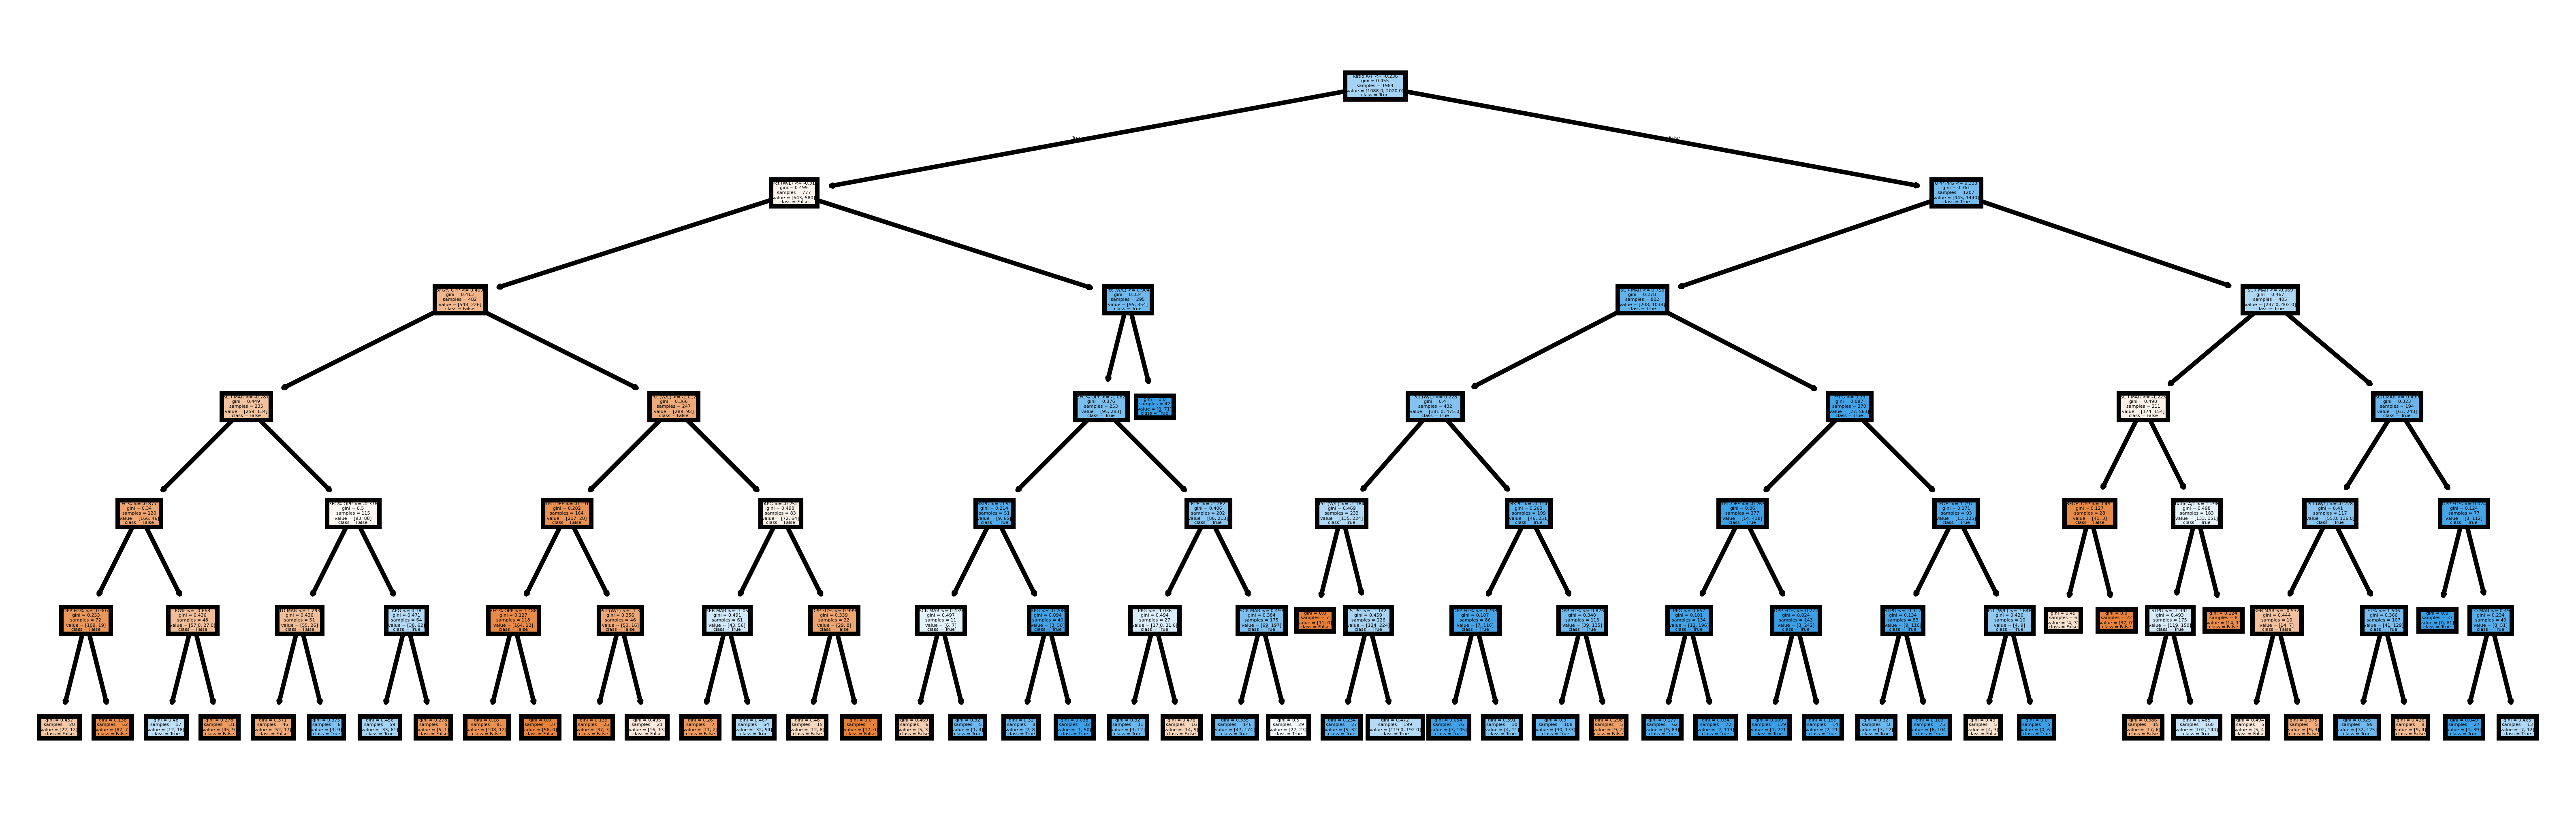

In [142]:
fn = x.columns
cn = label_encoder.classes_.astype(str)
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (10,3), dpi=800)
tree.plot_tree(rf_model_tuned.estimators_[0],
               feature_names = fn, 
               class_names=cn,
               filled = True);
fig.savefig('rf_individualtree.png')

In [ ]:
game_data.info()

In [ ]:
game_data.head()

In [ ]:
top_cols = [
    'Ratio A/T', 'APG', 'BKPG', 'RPG DEF', 'FG%', 'FT%', 'RPG OFF',	'PFPG',	'OPP RPG',	'RPG',	'REB MAR',	'OPP PPG',	'PPG',	'SCR MAR',	'STPG',	'Pct (W/L)', '3FG% OPP',	'3FG%',	'TO MAR', 'Home_winner?'
]
sampled_data = game_data[top_cols].sample(1000, random_state=42)
pairplot_fig = sns.pairplot(
    sampled_data,
    hue='Home_winner?',
    palette={0: 'red', 1: 'blue'},
    corner=True,
    diag_kind='hist',
    plot_kws={'s': 20, 'alpha': 0.7}
)

pairplot_fig.savefig("pairplot.png", dpi=300)

In [ ]:
features = [col for col in game_data.columns if col != 'Home_winner?']

# Determine subplot grid size
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
axes = axes.flatten()  # flatten to 1D for easy iteration

for i, feature in enumerate(features):
    sns.histplot(
        data=game_data,
        x=feature,
        hue='Home_winner?',
        bins=20,
        kde=False,
        palette={0:'red', 1:'blue'},
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(feature)
    
plt.tight_layout()
plt.show()
fig.savefig("all_features_histograms.png", dpi=300)



In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    game_data.drop(columns=['Home_winner?']).corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()
fig.savefig("Feature_correlation_heatmap.png", dpi=300)

In [ ]:
y_prob = rf_model_tuned.predict_proba(xtest)[:,1]
fpr, tpr, _ = roc_curve(ytest, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
fig.savefig("ROC_Curve.png", dpi=300)

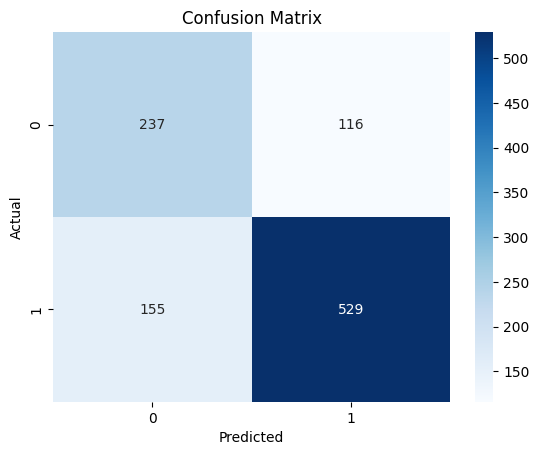

<Figure size 640x480 with 0 Axes>

In [181]:
sns.heatmap(
    confusion_matrix(ytest, rf_model_tuned.predict(xtest)),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plt.savefig("Confusion Matrix", dpi=300)

In [ ]:

features = [
    'Ratio A/T', 'APG', 'BKPG', 'RPG DEF', 'FG%', 'FT%',
    'RPG OFF', 'PFPG', 'OPP RPG', 'RPG',
    'REB MAR', 'OPP PPG', 'PPG', 'SCR MAR',
    'STPG', 'Pct (W/L)', '3FG% OPP', '3FG%', 'TO MAR'
]

disp = PartialDependenceDisplay.from_estimator(
    rf_model_tuned,
    xtest,
    features=features,
    feature_names=top_cols,
    n_cols=4,            # sklearn auto-calculates rows
    grid_resolution=50
)

disp.figure_.set_size_inches(18, 20)
disp.figure_.suptitle(
    "Partial Dependence Plots – Random Forest Model",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("partial_dependence.png", dpi=300, bbox_inches="tight")
plt.show()





In [166]:
with open("game_predictor_forest.pkl", "wb") as f:
    pickle.dump({
        "model": rf_model_tuned,
        "scaler": scaler,
        "feature_names": x.columns.tolist() 
}, open("game_predictor_forest.pkl", "wb"))


In [167]:
with open("game_predictor_forest.pkl", "rb") as f:
    saved = pickle.load(f)

model = saved["model"]
scaler = saved["scaler"]
feature_names = saved["feature_names"]


In [168]:
print(scaler.feature_names_in_)


['Ratio A/T' 'APG' 'BKPG' 'RPG DEF' 'FG%' 'OPP FG%' 'FT%' 'RPG OFF' 'PFPG'
 'OPP RPG' 'RPG' 'REB MAR' 'OPP PPG' 'PPG' 'SCR MAR' 'STPG' 'Pct (W/L)'
 '3FG% OPP' '3FG%' 'TO MAR']


In [173]:
march_madness_games = pd.read_csv('23-24MM Games&Stats.csv')


In [174]:
march_madness_games = march_madness_games.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed",	"Home Win %",	"Away Win %"])
march_madness_games.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,...,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,False,-0.39,1.1,0.7,-0.32,5.9,2.8,3.9,-0.26,3.7,...,-0.6,2.1,12.3,11.6,-0.7,0.1,1.3,4.1,5.2,-4.6
1,False,0.04,-3.2,1.9,-1.12,-5.4,-3.0,-11.7,1.06,-3.6,...,-0.1,-1.7,-8.8,-12.8,-3.9,0.6,-0.9,-2.7,2.2,2.2
2,False,0.39,3.3,-0.7,1.26,2.6,3.2,2.7,-2.83,2.5,...,-1.6,-3.4,5.1,7.5,2.5,0.8,-8.8,-0.5,2.8,2.5
3,False,-0.13,-3.4,0.3,-1.63,-4.1,0.2,-4.3,1.26,1.8,...,-0.4,-0.1,-3.7,-3.5,0.2,-0.1,-1.8,-0.7,-4.9,2.3
4,False,-0.58,-2.2,-0.8,1.46,-0.6,0.4,-3.4,2.26,0.2,...,3.8,5.1,3.2,1.7,-1.5,0.9,4.2,-3.4,-3.4,-3.1


In [175]:
march_madness_games = march_madness_games[feature_names]
march_madness_games.head()

,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,-0.39,1.1,0.7,-0.32,5.9,2.8,3.9,-0.26,3.7,-2.6,-0.6,2.1,12.3,11.6,-0.7,0.1,1.3,4.1,5.2,-4.6
1,0.04,-3.2,1.9,-1.12,-5.4,-3.0,-11.7,1.06,-3.6,1.6,-0.1,-1.7,-8.8,-12.8,-3.9,0.6,-0.9,-2.7,2.2,2.2
2,0.39,3.3,-0.7,1.26,2.6,3.2,2.7,-2.83,2.5,1.9,-1.6,-3.4,5.1,7.5,2.5,0.8,-8.8,-0.5,2.8,2.5
3,-0.13,-3.4,0.3,-1.63,-4.1,0.2,-4.3,1.26,1.8,-0.3,-0.4,-0.1,-3.7,-3.5,0.2,-0.1,-1.8,-0.7,-4.9,2.3
4,-0.58,-2.2,-0.8,1.46,-0.6,0.4,-3.4,2.26,0.2,-1.3,3.8,5.1,3.2,1.7,-1.5,0.9,4.2,-3.4,-3.4,-3.1


In [176]:
march_madness_games_scaled = scaler.transform(march_madness_games)


In [177]:
predictions = model.predict(march_madness_games_scaled)
print(predictions)


[1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1
 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [178]:
probabilities = model.predict_proba(march_madness_games_scaled)
print(probabilities)

[[0.41622744 0.58377256]
 [0.36172072 0.63827928]
 [0.52890694 0.47109306]
 [0.43186421 0.56813579]
 [0.43182879 0.56817121]
 [0.32830503 0.67169497]
 [0.37511127 0.62488873]
 [0.10151562 0.89848438]
 [0.12927904 0.87072096]
 [0.52950674 0.47049326]
 [0.32265322 0.67734678]
 [0.39484322 0.60515678]
 [0.59814467 0.40185533]
 [0.25793457 0.74206543]
 [0.20324554 0.79675446]
 [0.58558829 0.41441171]
 [0.12678202 0.87321798]
 [0.35527124 0.64472876]
 [0.55285628 0.44714372]
 [0.56115262 0.43884738]
 [0.36494441 0.63505559]
 [0.53460663 0.46539337]
 [0.34881629 0.65118371]
 [0.38944194 0.61055806]
 [0.54792392 0.45207608]
 [0.10904132 0.89095868]
 [0.28800933 0.71199067]
 [0.46732936 0.53267064]
 [0.23319701 0.76680299]
 [0.49226516 0.50773484]
 [0.09309883 0.90690117]
 [0.59088753 0.40911247]
 [0.15718117 0.84281883]
 [0.87680635 0.12319365]
 [0.2675918  0.7324082 ]
 [0.5061002  0.4938998 ]
 [0.36031388 0.63968612]
 [0.66724957 0.33275043]
 [0.31770896 0.68229104]
 [0.32950813 0.67049187]


In [179]:
games_for_output = pd.read_csv('23-24MM Games&Stats.csv')
results = pd.DataFrame(columns=["Home", "Away", "P_Home_Lose", "P_Home_Win","Home_win_bool"])
results["Home"] = games_for_output['Home_team']
results["Away"] = games_for_output['Away_Team']
results["P_Home_Lose"] = probabilities[:, 0]  # probability of home team losing
results["P_Home_Win"]  = probabilities[:, 1]  # probability of home team winning
results['Home_win_bool'] = predictions

results.head()

,Home,Away,P_Home_Lose,P_Home_Win,Home_win_bool
0,Howard,Wagner,0.416227,0.583773,1
1,Virginia,Colorado State,0.361721,0.638279,1
2,Montana State,Grambling,0.528907,0.471093,0
3,Boise State,Colorado,0.431864,0.568136,1
4,Mississippi State,Michigan State,0.431829,0.568171,1


In [161]:
game_data["Home_winner?"].value_counts(normalize=True)


Home_winner?
True     0.651679
False    0.348321
Name: proportion, dtype: float64

In [180]:

results.to_csv("march_madness_predictions.csv", index=False)